In [2]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models we will use for risk prediction
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Model evaluation tools
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [3]:
# Load the datasets
# These contain customer demographics, card information, and transaction behaviour

customers = pd.read_csv("cust_add.csv")
cards = pd.read_csv("cc_add.csv")
transactions = pd.read_csv("credit_card-2.csv")

# Check the size of each dataset
print("Customers dataset shape:", customers.shape)
print("Cards dataset shape:", cards.shape)
print("Transactions dataset shape:", transactions.shape)

Customers dataset shape: (185, 15)
Cards dataset shape: (185, 18)
Transactions dataset shape: (10108, 18)


In [8]:
# See column names in each dataset

print("Customers columns:")
print(customers.columns)

print("\nCards columns:")
print(cards.columns)

print("\nTransactions columns:")
print(transactions.columns)

Customers columns:
Index(['Client_Num', 'Customer_Age', 'Gender', 'Dependent_Count',
       'Education_Level', 'Marital_Status', 'state_cd', 'Zipcode', 'Car_Owner',
       'House_Owner', 'Personal_loan', 'contact', 'Customer_Job', 'Income',
       'Cust_Satisfaction_Score'],
      dtype='str')

Cards columns:
Index(['Client_Num', 'Card_Category', 'Annual_Fees', 'Activation_30_Days',
       'Customer_Acq_Cost', 'Week_Start_Date', 'Week_Num', 'Qtr',
       'current_year', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio',
       'Use Chip', 'Exp Type', 'Interest_Earned', 'Delinquent_Acc'],
      dtype='str')

Transactions columns:
Index(['Client_Num', 'Card_Category', 'Annual_Fees', 'Activation_30_Days',
       'Customer_Acq_Cost', 'Week_Start_Date', 'Week_Num', 'Qtr',
       'current_year', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Trans_Amt', 'Total_Trans_Vol', 'Avg_Utilization_Ratio',
       'Use Chip', 'Exp Type', 'I

In [9]:
# Merge only customers and card dataset
# The card dataset already contains transaction behaviour

full_data = pd.merge(customers, cards, on="Client_Num", how="inner")

print("Final dataset shape:", full_data.shape)

full_data.head()

Final dataset shape: (185, 32)


,Client_Num,Customer_Age,Gender,Dependent_Count,Education_Level,Marital_Status,state_cd,Zipcode,Car_Owner,House_Owner,...,current_year,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio,Use Chip,Exp Type,Interest_Earned,Delinquent_Acc
0,963607849,42,F,3,Uneducated,Married,CA,91750,no,no,...,2023,14315.0,690,9603,56,0.048,Swipe,Entertainment,598.69,0
1,932954954,62,F,0,High School,Unknown,NY,91750,yes,no,...,2023,5711.0,0,4325,72,0.000,Swipe,Fuel,691.20,0
2,961650885,47,F,3,Doctorate,Married,NJ,91750,no,no,...,2023,3104.0,1766,9353,24,0.569,Swipe,Travel,216.48,0
3,917695309,49,M,5,Graduate,Married,TX,91750,no,no,...,2023,2553.0,1823,3853,69,0.714,Chip,Grocery,1001.78,0
4,957309271,53,F,3,Graduate,Married,NY,91750,no,no,...,2023,2476.0,1944,4025,65,0.785,Chip,Fuel,845.25,0


In [11]:
# Create target variable for risk prediction

# In this dataset:
# 1 = delinquent customer
# 0 = normal customer

full_data["risk_flag"] = full_data["Delinquent_Acc"]

# Check distribution
full_data["risk_flag"].value_counts()

risk_flag
0    175
1     10
Name: count, dtype: int64

In [12]:
# Remove columns that should not be used for prediction

drop_cols = [
    "Client_Num",        # ID column
    "Delinquent_Acc",    # original target
    "Zipcode",           # too granular
    "contact"            # irrelevant feature
]

model_data = full_data.drop(columns=drop_cols)

print("Model dataset shape:", model_data.shape)

model_data.head()

Model dataset shape: (185, 29)


,Customer_Age,Gender,Dependent_Count,Education_Level,Marital_Status,state_cd,Car_Owner,House_Owner,Personal_loan,Customer_Job,...,current_year,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio,Use Chip,Exp Type,Interest_Earned,risk_flag
0,42,F,3,Uneducated,Married,CA,no,no,yes,Govt,...,2023,14315.0,690,9603,56,0.048,Swipe,Entertainment,598.69,0
1,62,F,0,High School,Unknown,NY,yes,no,no,Selfemployeed,...,2023,5711.0,0,4325,72,0.000,Swipe,Fuel,691.20,0
2,47,F,3,Doctorate,Married,NJ,no,no,no,Blue-collar,...,2023,3104.0,1766,9353,24,0.569,Swipe,Travel,216.48,0
3,49,M,5,Graduate,Married,TX,no,no,no,Businessman,...,2023,2553.0,1823,3853,69,0.714,Chip,Grocery,1001.78,0
4,53,F,3,Graduate,Married,NY,no,no,no,Selfemployeed,...,2023,2476.0,1944,4025,65,0.785,Chip,Fuel,845.25,0


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in model_data.columns:
    if model_data[col].dtype == "object" or model_data[col].dtype == "str":
        model_data[col] = le.fit_transform(model_data[col].astype(str))

model_data.head()

,Customer_Age,Gender,Dependent_Count,Education_Level,Marital_Status,state_cd,Car_Owner,House_Owner,Personal_loan,Customer_Job,...,current_year,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio,Use Chip,Exp Type,Interest_Earned,risk_flag
0,42,0,3,4,0,0,0,0,1,2,...,2023,14315.0,690,9603,56,0.048,2,1,598.69,0
1,62,0,0,2,2,7,1,0,0,4,...,2023,5711.0,0,4325,72,0.000,2,3,691.20,0
2,47,0,3,0,0,5,0,0,0,0,...,2023,3104.0,1766,9353,24,0.569,2,5,216.48,0
3,49,1,5,1,0,9,0,0,0,1,...,2023,2553.0,1823,3853,69,0.714,0,4,1001.78,0
4,53,0,3,1,0,7,0,0,0,4,...,2023,2476.0,1944,4025,65,0.785,0,3,845.25,0


In [16]:
model_data.dtypes

Customer_Age                 int64
Gender                       int64
Dependent_Count              int64
Education_Level              int64
Marital_Status               int64
state_cd                     int64
Car_Owner                    int64
House_Owner                  int64
Personal_loan                int64
Customer_Job                 int64
Income                       int64
Cust_Satisfaction_Score      int64
Card_Category                int64
Annual_Fees                  int64
Activation_30_Days           int64
Customer_Acq_Cost            int64
Week_Start_Date              int64
Week_Num                     int64
Qtr                          int64
current_year                 int64
Credit_Limit               float64
Total_Revolving_Bal          int64
Total_Trans_Amt              int64
Total_Trans_Ct               int64
Avg_Utilization_Ratio      float64
Use Chip                     int64
Exp Type                     int64
Interest_Earned            float64
risk_flag           

In [17]:
# Separate features (X) and target variable (y)

X = model_data.drop("risk_flag", axis=1)
y = model_data["risk_flag"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (185, 28)
Target shape: (185,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (148, 28)
Testing data: (37, 28)


In [19]:
from sklearn.linear_model import LogisticRegression

# Train model
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Model training completed")

Model training completed


/Users/aditidahare/Desktop/Sem Four/TransactIQ/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# Predict risk on test data

y_pred = lr_model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.918918918918919

Confusion Matrix
[[34  1]
 [ 2  0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        35
           1       0.00      0.00      0.00         2

    accuracy                           0.92        37
   macro avg       0.47      0.49      0.48        37
weighted avg       0.89      0.92      0.91        37



In [22]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr_balanced.fit(X_train, y_train)

print("Balanced model trained")

Balanced model trained


/Users/aditidahare/Desktop/Sem Four/TransactIQ/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
y_pred_bal = lr_balanced.predict(X_test)

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred_bal))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_bal))

print("\nClassification Report")
print(classification_report(y_test, y_pred_bal))

Accuracy: 0.8648648648648649

Confusion Matrix
[[32  3]
 [ 2  0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.91      0.93        35
           1       0.00      0.00      0.00         2

    accuracy                           0.86        37
   macro avg       0.47      0.46      0.46        37
weighted avg       0.89      0.86      0.88        37



In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained")

Random Forest model trained


In [26]:
y_pred_rf = rf_model.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9459459459459459

Confusion Matrix
[[35  0]
 [ 2  0]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        35
           1       0.00      0.00      0.00         2

    accuracy                           0.95        37
   macro avg       0.47      0.50      0.49        37
weighted avg       0.89      0.95      0.92        37



/Users/aditidahare/Desktop/Sem Four/TransactIQ/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aditidahare/Desktop/Sem Four/TransactIQ/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aditidahare/Desktop/Sem Four/TransactIQ/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [28]:
pip install imbalanced-learn


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training size:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)

Original training size: (148, 28)
After SMOTE: (280, 28)


In [30]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
y_pred_smote = rf_smote.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_smote))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report")
print(classification_report(y_test, y_pred_smote))

Accuracy: 0.918918918918919

Confusion Matrix
[[34  1]
 [ 2  0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        35
           1       0.00      0.00      0.00         2

    accuracy                           0.92        37
   macro avg       0.47      0.49      0.48        37
weighted avg       0.89      0.92      0.91        37



In [33]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained")

XGBoost model trained


In [34]:
y_pred_xgb = xgb_model.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8918918918918919

Confusion Matrix
[[33  2]
 [ 2  0]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        35
           1       0.00      0.00      0.00         2

    accuracy                           0.89        37
   macro avg       0.47      0.47      0.47        37
weighted avg       0.89      0.89      0.89        37



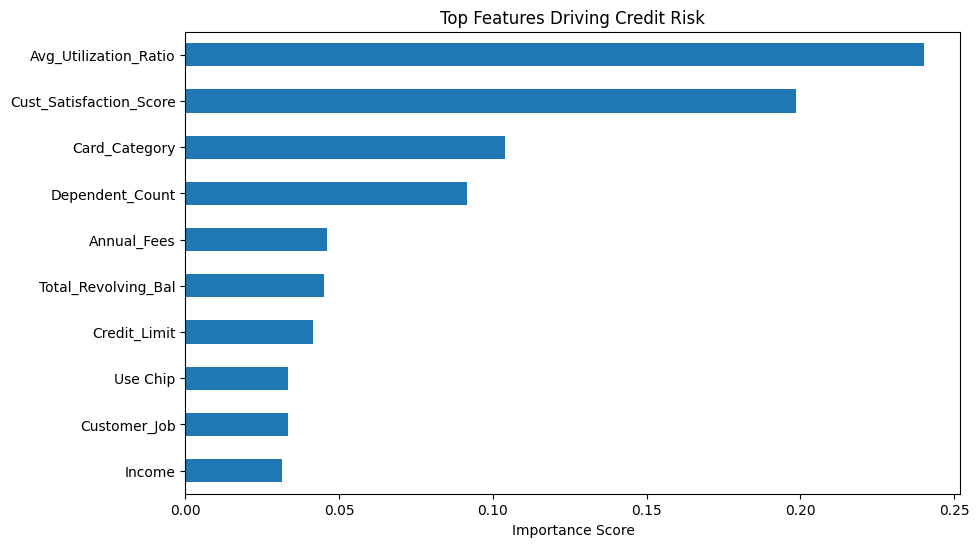

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance
importance = xgb_model.feature_importances_

features = pd.Series(importance, index=X.columns)

# Sort
features = features.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
features.head(10).plot(kind="barh")
plt.title("Top Features Driving Credit Risk")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()